# 14_损失函数-均方误差

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天和大家分享的是损失函数-均方误差（MSE，Mean Squared Error）。

我们先来理解一个大概念： **损失函数（Loss Function）**。

用大白话讲：**损失函数就是模型“猜错”的程度。猜得越离谱，损失越大；猜得越接近，损失越小。**

比如你让一个AI模型去预测你体重是多少公斤，你真实是60公斤：

- 如果模型说：59.9kg，那就几乎没猜错，损失很小；
- 如果模型说：90kg，那就离谱了，损失很大。

## 均方误差

均方误差是最常用的一种损失函数。

- **误差（Error）**：就是“预测值” - “真实值”。
- **平方（Squared）**：为了避免正负抵消（比如猜低了 -5，猜高了 +5，平均是0，其实都错了），我们把每个误差的平方算进去。
- **平均（Mean）**：把所有样本的平方误差求平均，得到整体的预测误差。

所以，**均方误差**就是：**把每个样本的预测误差平方后，再求所有样本的平均值**。

#### 举个通俗例子：

假设你训练了一个模型，让它预测房价。你有 3 个样本，真实房价如下：

| 样本 | 真实值（y） | 预测值（ŷ） | 误差（ŷ - y） | 平方误差 |
|-|-|-|-|-|
| 1 | 100万 | 110万 | +10万 | 100000000 |
| 2 | 150万 | 140万 | -10万 | 100000000 |
| 3 | 200万 | 180万 | -20万 | 400000000 |

现在求平均平方误差（MSE）：

MSE = (100000000 + 100000000 + 400000000) / 3

MSE = 200,000,000（单位：元²）

这个 2 亿的数字就是你模型目前的平均“猜错程度”。

## MSE 数学定义

### 1. 数学公式：

设：

- $y_i$：第 i 个样本的真实值
- $\hat{y}_i$：第 i 个样本的预测值
- $n$：样本总数量

那么均方误差的公式为：


$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$


### 2. 每个部分解释：

- $y_i - \hat{y}_i$：预测值和真实值的误差（偏差）
- $(y_i - \hat{y}_i)^2$：误差平方，确保全部为正，放大大的错误
- $\sum$：把所有样本的误差平方加在一起
- $\frac{1}{n}$：对样本数量做平均，得到总体表现

**这里，有个问题，为什么用平方？**

1. **防止正负误差抵消**：有些预测偏高、有些偏低，相互抵消看起来没错，其实都错了。平方后全是正数。
2. **惩罚大的错误**：平方后，大的误差变得更大。比如误差是 2 和 10，平方后是 4 和 100。说明模型错得离谱时，惩罚更重。
3. **可导（方便优化）**：平方是光滑、连续、可导的函数，这对后续的梯度下降等优化算法很友好。

## MSE 最小化目标 & 梯度下降的思路

在机器学习中，我们的目标是：

**让 MSE 越小越好**（也就是预测越准）

为了最小化 MSE，我们使用优化算法，比如 **梯度下降法（Gradient Descent）**。

核心想法是：

- 看看当前的模型参数让 MSE 变大还是变小；
- 如果 MSE 在变大，就反方向走一点；
- 不断重复，直到找到最低点（损失最小，模型最准确）

## MSE 的优化流程（算法流程）

这里是训练时使用 MSE 的标准流程：

### 训练过程中：

1. **初始化模型参数**（比如线性回归的权重）
2. **输入训练样本**（一组 $x_i$）
3. **模型预测输出** $\hat{y}_i$（根据当前参数计算）
4. **计算 MSE 损失**：


$$
L = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$


1. **计算损失对模型参数的导数**（反向传播）
2. **用梯度下降更新参数**：

$\theta := \theta - \eta \cdot \frac{\partial L}{\partial \theta}$

其中 $\eta$ 是学习率

1. **重复迭代，直到损失收敛**

## 完整案例

这里的案例模拟了一个常见的数据科学问题，**根据房屋面积、卧室数、房龄预测房价**。

这是一个典型的回归问题。我们使用「线性回归 + 均方误差」来建模和评估预测效果。

### 模拟数据构建

我们创建了如下字段：

- `Area`: 房屋面积（平方）
- `Bedrooms`: 卧室数量（1\~4）
- `Age`: 房龄（年）
- `Price`: 房价（模拟真实值 + 随机噪声）

数据量为 200 条，模拟现实世界中房价受多个因素影响的情况。

#### 可视化 1：房价与面积的关系

我们使用 `Seaborn` 绘制了一个散点图，颜色代表卧室数，气泡大小代表房龄。清晰地展示了特征之间的关系。

#### 可视化 2：特征相关性热图

使用 `heatmap` 展示了特征间的线性相关性，便于观察哪些变量对价格影响大（比如 Area 与 Price 相关性较高）。

### 建模过程：线性回归 + MSE

#### 1. 数据拆分

我们将数据集拆分为训练集（80%）和测试集（20%），确保模型不会“背答案”。

#### 2. 训练模型

使用 Scikit-learn 的 `LinearRegression` 对训练集进行建模。

#### 3. 模型预测

在测试集上进行预测，得到每个样本的预测房价。

### 评估模型：均方误差（MSE）

我们使用 **均方误差（MSE）** 和 **平均绝对误差（MAE）** 来衡量模型效果。

### 完整代码

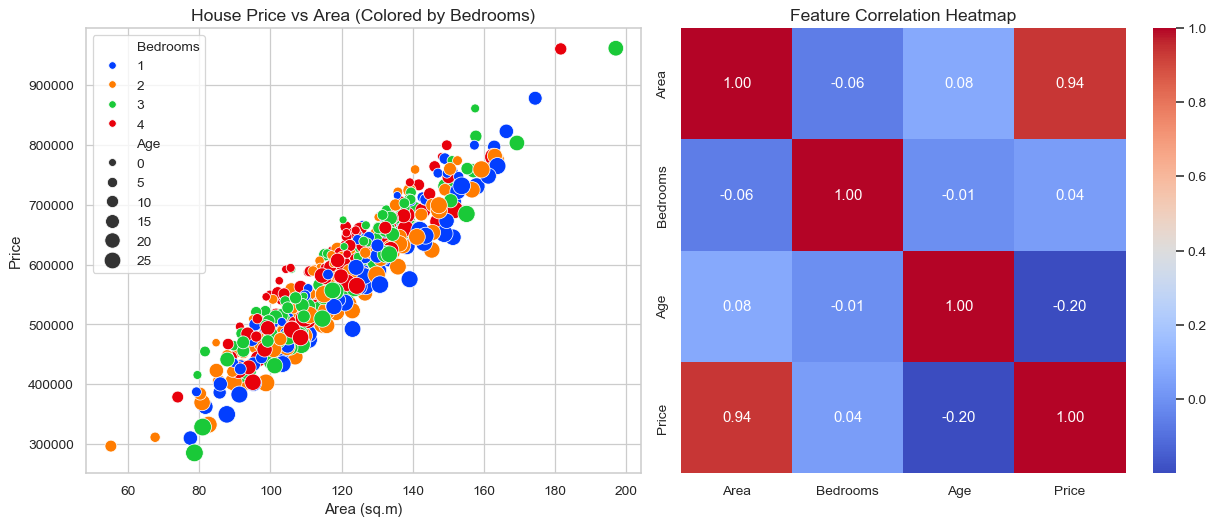

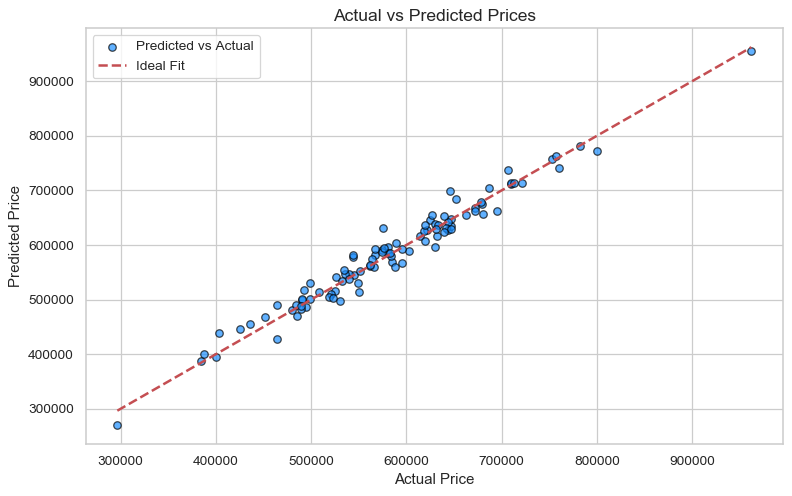

343648891.2508166
14237.557190014455


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

sns.set(style="whitegrid")

plt.rcParams['font.sans-serif'] = CJK_FONTS
# 创建一个模拟的房价数据集
np.random.seed(42)
n_samples = 500

# 特征
area = np.random.normal(120, 20, n_samples)  # 房屋面积
bedrooms = np.random.randint(1, 5, n_samples)  # 卧室数
age = np.random.randint(0, 30, n_samples)  # 房龄

# 构造目标值（房价），加入噪声
price = 5000 * area + 10000 * bedrooms - 3000 * age + np.random.normal(0, 20000, n_samples)

# 构造DataFrame
df = pd.DataFrame({
    'Area': area,
    'Bedrooms': bedrooms,
    'Age': age,
    'Price': price
})

# 可视化数据分布
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x='Area', y='Price', hue='Bedrooms', size='Age', sizes=(40, 200), palette='bright', data=df)
plt.title("House Price vs Area (Colored by Bedrooms)", fontsize=14)
plt.xlabel("Area (sq.m)")
plt.ylabel("Price")

plt.subplot(1, 2, 2)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap", fontsize=14)

plt.tight_layout()
plt.show()

# 数据预处理：划分训练集和测试集
X = df[['Area', 'Bedrooms', 'Age']]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 建立线性回归模型
model = LinearRegression()
model.fit(X_train, y_train)

# 预测
y_pred = model.predict(X_test)

# 计算损失函数：均方误差
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# 可视化预测结果
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='dodgerblue', edgecolors='black', alpha=0.7, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.title("Actual vs Predicted Prices", fontsize=14)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.grid(True)
plt.show()

print(mse)
print(mae)

### 结果如下：

- **均方误差 MSE** ≈ 343648891 元²
- **平均绝对误差 MAE** ≈ 14237 元

说明：平均每套房价的预测值与真实值相差约 1.4 万元左右，误差在允许范围。

### 可视化结果分析

**实际值 vs 预测值**：横轴是真实价格，纵轴是模型预测价格，红色虚线是理想预测（完全正确的预测线），蓝色点越接近红线，说明预测越准确

![原文参考图，当前结果见代码输出](attachments/img_010.png)

![原文参考图，当前结果见代码输出](attachments/img_011.png)

可以看到大部分点分布在红线附近，表明模型预测性能较好。

## 模型分析

#### 优点

1. **对大误差更敏感**：平方操作会放大大误差样本，模型被驱动去优化极端误差。
2. **数学上平滑可导**：对模型优化非常友好（梯度下降等算法可以很好地处理它）。
3. **凸函数，解唯一**：理论上更容易找到全局最优解。

#### 缺点

1. **对离群值过于敏感**：一个非常大的误差会严重影响整体损失。
2. **单位是“平方”，难解释**：单位不是“元”，而是“元²”，直觉不强。
3. **过拟合风险大**：模型可能为了最小化平方误差而过度拟合极端值。

### 与相似算法对比

我们对比几种常用的回归损失函数：

| 损失函数 | 对离群值敏感 | 可导性 | 优点 | 缺点 |
|-|-|-|-|-|
| MSE | 高 | 是 | 惩罚大误差严重，优化稳定 | 受异常值影响大，单位不好解释 |
| MAE | 低 | 不完全 | 鲁棒，抗离群值能力强 | 不连续可导，梯度下降不稳定 |
| Huber 损失 | 中 | 是 | 结合 MSE 和 MAE 优点 | 需要调整超参数 delta |
| Log-Cosh 损失 | 中 | 是 | 平滑，惩罚小误差不严重 | 收敛速度慢 |

### 适合使用 MSE 的场景：

- **数据质量好、离群值少**：例如工业传感器精度高、房价系统误差稳定
- **需要精确拟合整体趋势**：比如金融预测、市场回归分析
- **模型优化稳定性重要**：特别是使用神经网络、梯度下降等算法

### 不适合 MSE 的场景：

- 数据中有大量异常点（比如社交媒体用户数据）
- 想保持预测的鲁棒性而不是精度（更适合用 MAE 或 Huber）